In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_mnli_m_gemma_2_9b_it_4bit_few_shot_1_examples_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_mnli_m_gemma_2_9b_it_4bit_few_shot_1_examples_neutral_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_mnli_m_gemma_2_9b_it_4bit_few_shot_1_examples_contradiction_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_mnli_m_gemma_2_9b_it_4bit_few_shot_3_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_gemma_2_9b_it/Results/checkpoint_mnli_m_gemma_2_9b_it_4bit_few_sho

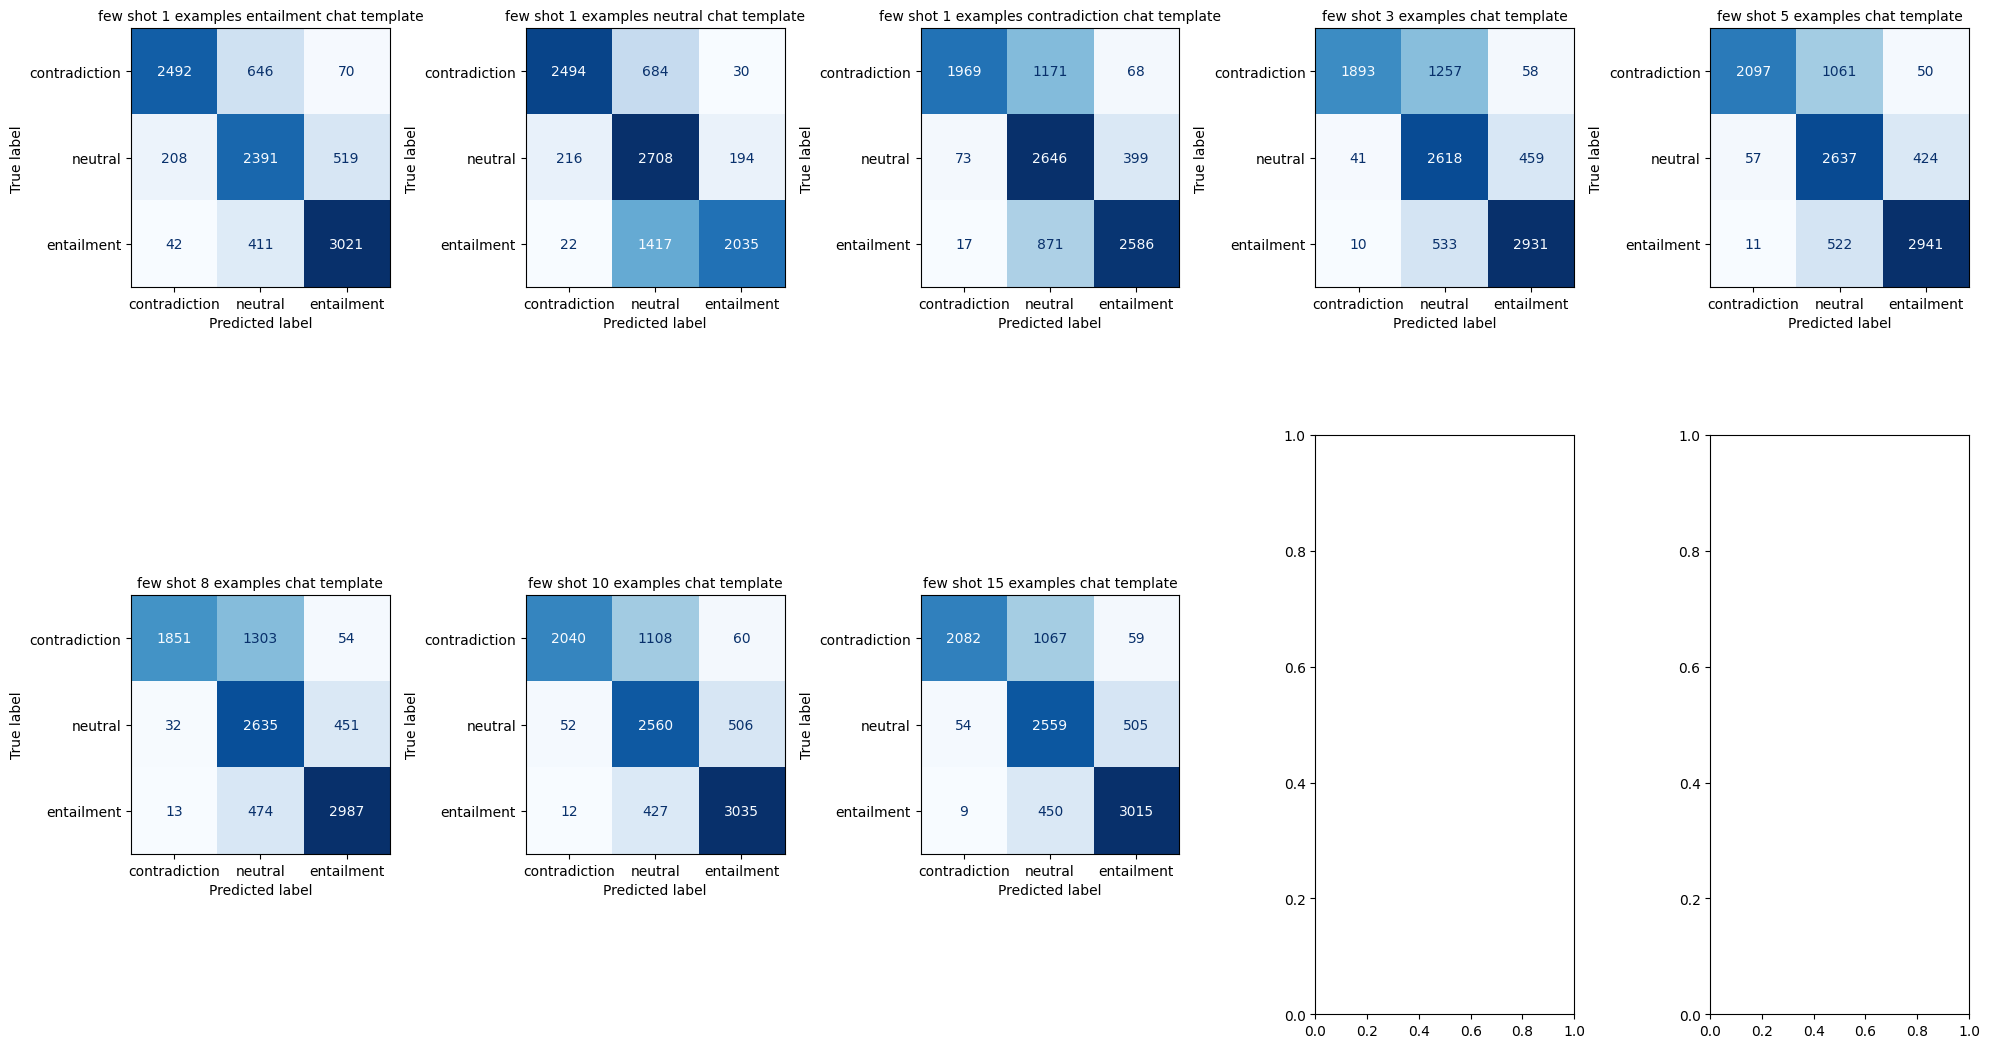

In [ ]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples entailment chat template',
    'few shot 1 examples neutral chat template',
    'few shot 1 examples contradiction chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for mode in training_modes:
    global_params = {
            'dataset_type': 'mnli_m',
            'quantization': '4bit',
            'training_mode': mode,
            'model_id': 'google/gemma-2-9b-it'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
labels = [
    "0 examples"
    "1 example (entailment)",
    "1 example (neutral)",
    "1 example (contradiction)",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 example (entailment),0.8065,0.8130,0.8044,0.8063,0.7114,0.7095
1 example (neutral),0.7385,0.7923,0.7439,0.7443,0.6328,0.6102
1 example (contradiction),0.7348,0.7892,0.7356,0.7393,0.6228,0.6033
3 examples,0.7594,0.8059,0.7578,0.7591,0.6563,0.6394
5 examples,0.7832,0.8182,0.7820,0.7844,0.6874,0.6750
8 examples,0.7626,0.8096,0.7606,0.7609,0.6618,0.6441
10 examples,0.7791,0.8125,0.7769,0.7786,0.6803,0.6685
15 examples,0.7812,0.8136,0.7792,0.7814,0.6828,0.6718


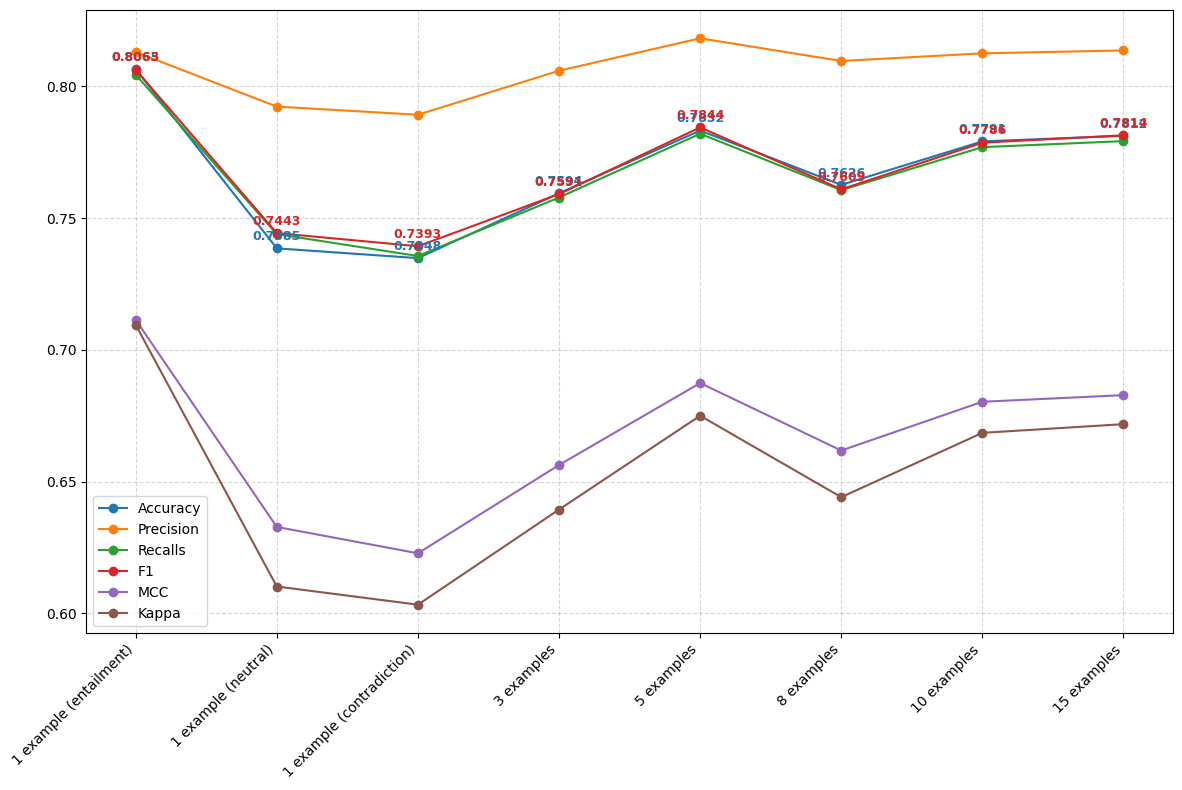

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()